# YouTube Comments Cleaning & Sentiment Analysis

This notebook cleans the YouTube comments dataset, classifies each comment as **Positive**, **Negative**, or **Neutral**, and calculates the sentiment percentages.

**Method used:** TextBlob polarity score  
- Polarity > 0.05 = Positive  
- Polarity < 0.05 = Negative  
- Otherwise = Neutral


In [1]:
# Install TextBlob if you do not have it
# Run this cell only once if TextBlob is not installed


!pip install transformers torch
!pip install vaderSentiment
!pip install malaya

In [2]:
import pandas as pd
import re
import html
from textblob import TextBlob
import matplotlib.pyplot as plt

## 1. Load the dataset

In [3]:
# Make sure your CSV file is in the same folder as this notebook
file_path = "youtube_comments_all.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5388, 8)


,video_id,user,comment,likes,published_at,reply_count,type,parent_id
0,XR6OO2ScEXU,@kieranjohnston7550,I came to Malaysia 40 years ago to marry a Mal...,1050,2025-07-27 08:53,82,top_level,NaN
1,DJJvt9_6dNE,@shakochon,Going to KL really changed my perspective abou...,601,2024-07-09 13:26,20,top_level,NaN
2,DJJvt9_6dNE,@drand9585,I am a single western woman. I travelled to K...,505,2024-07-09 16:29,60,top_level,NaN
3,XR6OO2ScEXU,@thecloudchaser1,As a Malaysian living overseas .. it amuses me...,444,2025-07-30 08:36,1,top_level,NaN
4,DJJvt9_6dNE,@AnonozChong,"I am a Malaysian, used to nomad throughout the...",441,2024-07-09 12:22,26,top_level,NaN


## 2. Check columns and missing values

In [4]:
df.info()
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5388 entries, 0 to 5387
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   video_id      5388 non-null   object
 1   user          5388 non-null   object
 2   comment       5386 non-null   object
 3   likes         5388 non-null   int64 
 4   published_at  5388 non-null   object
 5   reply_count   5388 non-null   int64 
 6   type          5388 non-null   object
 7   parent_id     3003 non-null   object
dtypes: int64(2), object(6)
memory usage: 336.9+ KB

Missing values:
video_id           0
user               0
comment            2
likes              0
published_at       0
reply_count        0
type               0
parent_id       2385
dtype: int64


## 3. Clean the comments

In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 3  –  Install dependencies (run once)
# ─────────────────────────────────────────────────────────────
!pip install nltk spacy malaya
!python -m spacy download en_core_web_sm

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 6.0 MB/s eta 0:00:03
     ---- ----------------------------------- 1.3/12.8 MB 4.1 MB/s eta 0:00:03
     ------ --------------------------------- 2.1/12.8 MB 4.7 MB/s eta 0:00:03
     ---------- ----------------------------- 3.4/12.8 MB 4.5 MB/s eta 0:00:03
     ------------ --------------------------- 3.9/12.8 MB 4.1 MB/s eta 0:00:03
     -------------- ------------------------- 4.7/12.8 MB 4.1 MB/s eta 0:00:02
     ------------------ --------------------- 5.8/12.8 MB 4.3 MB/s eta 0:00:02
     -------------------- ------------------- 6.6/12.8 MB 4.3 MB/s eta 0:00:02
     ------------------------ --------------- 7.9/12.8 MB 4.4 MB/s eta 0:00:02
     ---------------------------- ----------- 9.2/12.8 MB 4.6 MB/s eta 0:00:01
     -------------------------------- ------- 10.5/12.8 MB 4.8 MB/s eta 0:00:01
     ------------------------------------ --- 11.5/12.8 MB

[nltk_data] Downloading package punkt to C:\Users\ASUS TUF
[nltk_data]     GAMING\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\ASUS TUF
[nltk_data]     GAMING\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\ASUS TUF
[nltk_data]     GAMING\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\ASUS TUF
[nltk_data]     GAMING\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\ASUS TUF
[nltk_data]     GAMING\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 3B  –  Import NLP tools & build stop word list
# ─────────────────────────────────────────────────────────────
import re
import html
import malaya
import spacy
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# English tools
nlp_en        = spacy.load("en_core_web_sm")
lemmatizer    = WordNetLemmatizer()
en_stopwords  = set(stopwords.words('english'))

# Malay stop words via Malaya
my_stopwords  = set(malaya.text.function.get_stopwords())

# Combined stop word set
all_stopwords = en_stopwords | my_stopwords

print(f"English stop words: {len(en_stopwords)}")
print(f"Malay stop words  : {len(my_stopwords)}")
print(f"Combined total    : {len(all_stopwords)}")

C:\Users\ASUS TUF GAMING\anaconda3\Lib\site-packages\malaya\tokenizer.py:214: FutureWarning: Possible nested set at position 3397
  self.tok = re.compile(r'({})'.format('|'.join(pipeline)))
C:\Users\ASUS TUF GAMING\anaconda3\Lib\site-packages\malaya\tokenizer.py:214: FutureWarning: Possible nested set at position 3927
  self.tok = re.compile(r'({})'.format('|'.join(pipeline)))


English stop words: 198
Malay stop words  : 1057
Combined total    : 1253


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 3C  –  Full preprocessing pipeline
# ─────────────────────────────────────────────────────────────
def clean_comment(text):
    """Step 1 – Basic noise removal (same as before)."""
    text = str(text)
    text = html.unescape(text)                        # HTML symbols → plain text
    text = re.sub(r'http\S+|www\.\S+', '', text)     # Remove URLs
    text = re.sub(r'@\w+', '', text)                  # Remove @mentions
    text = re.sub(r'#', '', text)                     # Remove hashtag symbol
    text = re.sub(r'[^\w\s]', '', text)               # Remove punctuation
    text = re.sub(r'\d+', '', text)                   # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()          # Collapse whitespace
    return text.lower()                               # Lowercase


def tokenize(text):
    """Step 2 – Tokenization: split text into individual word tokens."""
    return word_tokenize(text)          # e.g. "good phone" → ["good", "phone"]


def remove_stopwords(tokens):
    """Step 3 – Stop word removal: drop common filler words (EN + MY)."""
    return [t for t in tokens if t not in all_stopwords and len(t) > 1]


def lemmatize_tokens(tokens):
    """Step 4 – Lemmatization: reduce words to their dictionary base form.
       Uses spaCy for English; Malay words are left as-is (no mature lemmatizer).
    """
    lemmatized = []
    for token in tokens:
        doc = nlp_en(token)
        lemma = doc[0].lemma_ if doc else token
        # spaCy returns '-PRON-' or the token itself for unknown words
        lemmatized.append(lemma if lemma != '-PRON-' else token)
    return lemmatized


def preprocess(text):
    """Full pipeline: clean → tokenize → remove stop words → lemmatize → rejoin."""
    text   = clean_comment(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    return ' '.join(tokens)             # Rejoin for TextBlob sentiment scoring


# Apply to the dataframe
df['comment_clean'] = df['comment'].apply(preprocess)

# Remove duplicates and empty rows
df = df.drop_duplicates(subset=['user', 'comment_clean', 'published_at'], keep='first')
df = df[df['comment_clean'].str.len() > 0]

print("Cleaned dataset shape:", df.shape)
df[['comment', 'comment_clean']].head(10)

Cleaned dataset shape: (4472, 9)


,comment,comment_clean
0,I came to Malaysia 40 years ago to marry a Mal...,come malaysia year ago marry malay woman study...
1,Going to KL really changed my perspective abou...,go kl really change perspective western city w...
2,I am a single western woman. I travelled to K...,single western woman travel kl malaysia indone...
3,As a Malaysian living overseas .. it amuses me...,malaysian live overseas amuse see video like t...
4,"I am a Malaysian, used to nomad throughout the...",malaysian use nomad throughout america europe ...
5,"I've done both Dubai and KL. KL is underrated,...",I do dubai kl kl underrated dubai way rat
6,I grew up in Europe but never liked the harsh ...,grow europe never like harsh winter use day se...
7,As a Canadian I consider Malaysia the best cou...,canadian consider malaysia well country live w...
8,I have lived in Malaysia for the last 15 years...,live malaysia year love still pro correct woul...
9,Sepatutnya ujudkan semula Sekolah Vokasional P...,ujudkan sekolah vokasional pertanian sekolah b...


## 4. Sentiment analysis

In [8]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_polarity(text):
    return analyzer.polarity_scores(text)['compound']

def get_sentiment(polarity):
    if polarity > 0.05:
        return "Positive"
    elif polarity < -0.05:
        return "Negative"
    else:
        return "Neutral"

df['polarity'] = df['comment_clean'].apply(get_polarity)
df['sentiment'] = df['polarity'].apply(get_sentiment)

df[['comment_clean', 'polarity', 'sentiment']].head(10)

,comment_clean,polarity,sentiment
0,come malaysia year ago marry malay woman study...,0.2732,Positive
1,go kl really change perspective western city w...,0.8442,Positive
2,single western woman travel kl malaysia indone...,0.0000,Neutral
3,malaysian live overseas amuse see video like t...,0.8519,Positive
4,malaysian use nomad throughout america europe ...,0.8687,Positive
5,I do dubai kl kl underrated dubai way rat,0.0000,Neutral
6,grow europe never like harsh winter use day se...,0.8315,Positive
7,canadian consider malaysia well country live w...,0.7003,Positive
8,live malaysia year love still pro correct woul...,0.9171,Positive
9,ujudkan sekolah vokasional pertanian sekolah b...,0.0000,Neutral


## 5. Count and percentage of sentiments

In [9]:
sentiment_count = df['sentiment'].value_counts().reindex(['Positive', 'Negative', 'Neutral']).fillna(0).astype(int)

sentiment_summary = pd.DataFrame({
    'sentiment': sentiment_count.index,
    'count': sentiment_count.values,
    'percentage_all_comments': (sentiment_count.values / len(df) * 100).round(2)
})

# Positive/negative percentage only, excluding neutral
pos_neg_total = sentiment_summary[sentiment_summary['sentiment'].isin(['Positive', 'Negative'])]['count'].sum()

sentiment_summary['percentage_positive_negative_only'] = sentiment_summary.apply(
    lambda row: round(row['count'] / pos_neg_total * 100, 2)
    if row['sentiment'] in ['Positive', 'Negative'] and pos_neg_total > 0
    else None,
    axis=1
)

sentiment_summary

,sentiment,count,percentage_all_comments,percentage_positive_negative_only
0,Positive,2115,47.29,79.12
1,Negative,558,12.48,20.88
2,Neutral,1799,40.23,NaN


## 6. Filter positive and negative comments

In [10]:
positive_comments = df[df['sentiment'] == 'Positive']
negative_comments = df[df['sentiment'] == 'Negative']

print("Positive comments:", len(positive_comments))
print("Negative comments:", len(negative_comments))

positive_comments[['user', 'comment_clean', 'polarity']].head()

Positive comments: 2115
Negative comments: 558


,user,comment_clean,polarity
0,@kieranjohnston7550,come malaysia year ago marry malay woman study...,0.2732
1,@shakochon,go kl really change perspective western city w...,0.8442
3,@thecloudchaser1,malaysian live overseas amuse see video like t...,0.8519
4,@AnonozChong,malaysian use nomad throughout america europe ...,0.8687
6,@insiderm37,grow europe never like harsh winter use day se...,0.8315


In [11]:
negative_comments[['user', 'comment_clean', 'polarity']].head()

,user,comment_clean,polarity
11,@TedPatrickBaird,spend two month kuala lumpur definitely say pr...,-0.5859
15,@tiengwy,pro worry major earthquake volcanic eruption t...,-0.4404
50,@ZagiNoa,fzme he spread misinformation he troll,-0.3182
61,@tharwatjad9444,frankfurt main train station that what wrong w...,-0.4767
91,@AbdulRazak-z3x,say miss spring autumn year ago today climate,-0.1531


## 7. Visualize the result

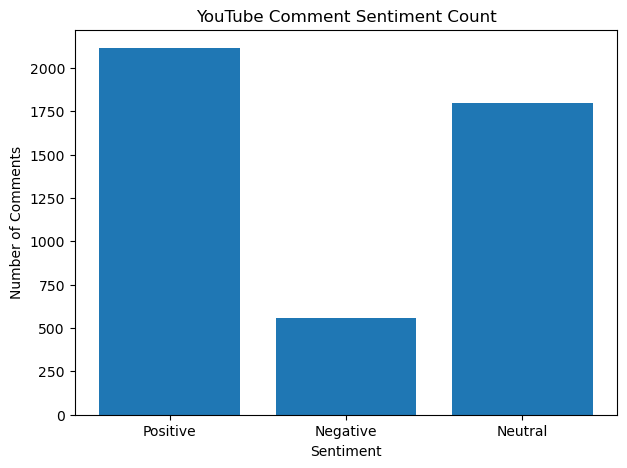

In [12]:
plt.figure(figsize=(7,5))
plt.bar(sentiment_summary['sentiment'], sentiment_summary['count'])
plt.title('YouTube Comment Sentiment Count')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.show()

## 8. Save the cleaned files

In [13]:
df.to_csv("youtube_comments_with_sentiment.csv", index=False)
positive_comments.to_csv("positive_comments.csv", index=False)
negative_comments.to_csv("negative_comments.csv", index=False)
sentiment_summary.to_csv("sentiment_summary.csv", index=False)

print("Files saved successfully.")

Files saved successfully.
